In [4]:
import pandas as pd
import plotly.express as px

In [5]:
# First re-import the station metadata!
station_metadata = pd.read_csv('GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')


In [6]:
oxygen_df = pd.merge(oxygen_df, station_metadata, how='left', left_on='GEMS.Station.Number', right_on='GEMS Station Number')


NameError: name 'oxygen_df' is not defined

/var/folders/4b/sly201491lz119kc400w1qrm0000gn/T/ipykernel_59225/2774100669.py:6: DtypeWarning:

Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.



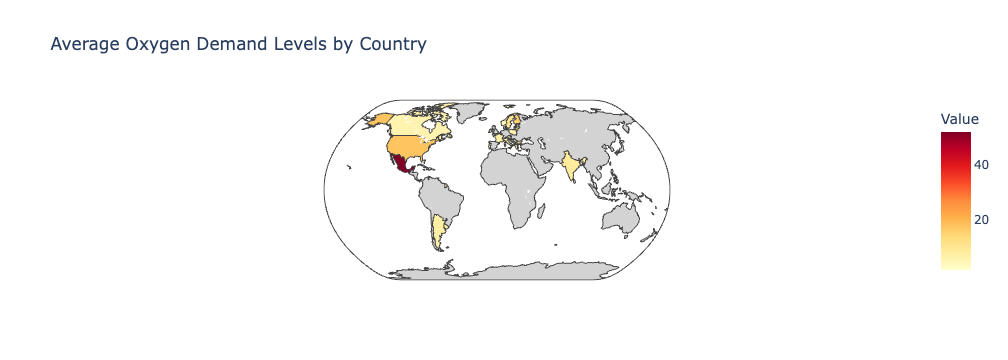

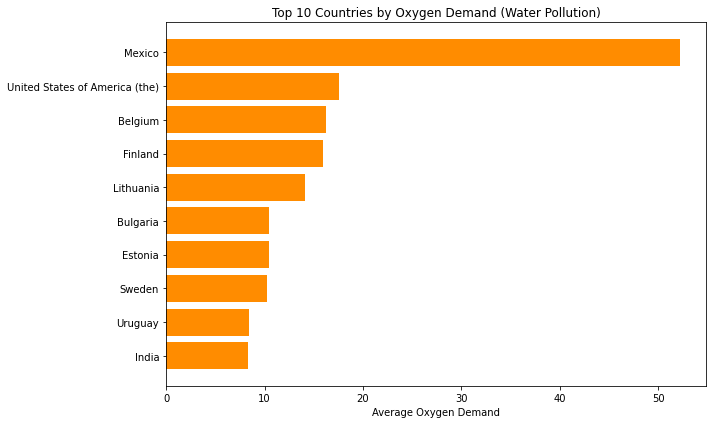

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load Oxygen Demand data
oxygen_df = pd.read_csv('Oxygen_Demand.csv', sep=';')  # Make sure separator matches

# If necessary: add country info like we did before
oxygen_df = pd.merge(oxygen_df, station_metadata, how='left', left_on='GEMS.Station.Number', right_on='GEMS Station Number')

# Calculate average oxygen demand per country
oxygen_by_country = oxygen_df.groupby('Country Name')['Value'].mean().reset_index()

# Plot as world map
fig = px.choropleth(
    oxygen_by_country,
    locations='Country Name',
    locationmode='country names',
    color='Value',
    color_continuous_scale='YlOrRd',
    title='Average Oxygen Demand Levels by Country'
)

fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

fig.show()
fig.write_html("oxygen_map.html", include_plotlyjs='cdn')



# OPTIONAL: Top 10 worst countries
top10_oxygen = oxygen_by_country.sort_values(by='Value', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_oxygen['Country Name'], top10_oxygen['Value'], color='darkorange')
plt.xlabel('Average Oxygen Demand')
plt.title('Top 10 Countries by Oxygen Demand (Water Pollution)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# Load data
oxygen_df = pd.read_csv('Oxygen_Demand.csv', sep=';', low_memory=False)
station_metadata = pd.read_csv('GEMStat_station_metadata.csv', sep=';', encoding='ISO-8859-1')

# Clean columns
oxygen_df.columns = oxygen_df.columns.str.strip()
station_metadata.columns = station_metadata.columns.str.strip()

# Rename for merge
station_metadata.rename(columns={'GEMS Station Number': 'GEMS.Station.Number'}, inplace=True)

# Merge to get country info
merged = pd.merge(oxygen_df, station_metadata, how='left', on='GEMS.Station.Number')

# Parse dates and extract year
merged['Sample.Date'] = pd.to_datetime(merged['Sample.Date'], errors='coerce')
merged['Year'] = merged['Sample.Date'].dt.year

# Keep valid rows
merged['Value'] = pd.to_numeric(merged['Value'], errors='coerce')
merged = merged.dropna(subset=['Value', 'Year', 'Country Name'])

# Group by country and year
summary = merged.groupby(['Country Name', 'Year'])['Value'].mean().reset_index()
summary.columns = ['Country', 'Year', 'Average Oxygen Demand (mg/L)']

# Add interpretation
def interpret(val):
    if val > 8:
        return "High pollution"
    elif val > 4:
        return "Moderate pollution"
    else:
        return "Low pollution"

summary['Notes'] = summary['Average Oxygen Demand (mg/L)'].apply(interpret)

# Save for Froggy
summary.to_csv('oxygen_demand_country_year.csv', index=False)
print("CSV saved as 'oxygen_demand_country_year.csv'")


CSV saved as 'oxygen_demand_country_year.csv'
